# Emotion Cipher AI - Exploratory Data Analysis (EDA)
This notebook performs an initial exploratory data analysis on the robust \`goemotions\` datasets located inside the \`backend/full_dataset\` directory. 

We visualize the distribution of emotions, text sequence lengths, and words to provide intuition for ML/NLP engineering.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import glob

import os

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Data Loading
Loading the CSV splits into a unified Pandas DataFrame.


In [6]:
dataset_dir = "full_dataset"
csv_files = glob.glob(os.path.join(dataset_dir, "*.csv"))

df_list = []
for file in csv_files:
    print(f"Reading {file}...")
    df_list.append(pd.read_csv(file))
    
# Combine all parts
full_df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal Samples: {full_df.shape[0]}")
print(f"Total Columns: {full_df.shape[1]}")

display(full_df.head(3))


Reading full_dataset\goemotions_1.csv...
Reading full_dataset\goemotions_2.csv...
Reading full_dataset\goemotions_3.csv...

Total Samples: 211225
Total Columns: 37


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1


## 2. Preparing Emotion Targets
The GoEmotions dataset labels are one-hot encoded. We will aggregate them to find the dominant emotion for each text block.


In [7]:
non_emotion_cols = ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear']
emotion_cols = [col for col in full_df.columns if col not in non_emotion_cols]

# For visualization, let's grab the first active emotion index per text (or 'neutral')
# To keep this fast over 200k rows, we can just use idxmax on the subset
emotion_subset = full_df[emotion_cols]

# Find the dominant emotion (where the value is 1)
# idxmax() brings the column name of the max value. If the row is all 0s, it takes the first col, so we need to handle that.
dominant_emotions = emotion_subset.idxmax(axis=1)

# Only assign it if at least one emotion was active (sum > 0), else label as neutral
active_sums = emotion_subset.sum(axis=1)
full_df['dominant_emotion'] = np.where(active_sums > 0, dominant_emotions, 'neutral')

print("Assigned dominant emotion strings.")
display(full_df[['text', 'dominant_emotion']].head(5))


Assigned dominant emotion strings.


,text,dominant_emotion
0,That game hurt.,sadness
1,>sexuality shouldn’t be a grouping category I...,neutral
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral


## 3. Emotion Label Distribution
Visualizing the frequency of each emotion in the dataset to see if there are class imbalances.


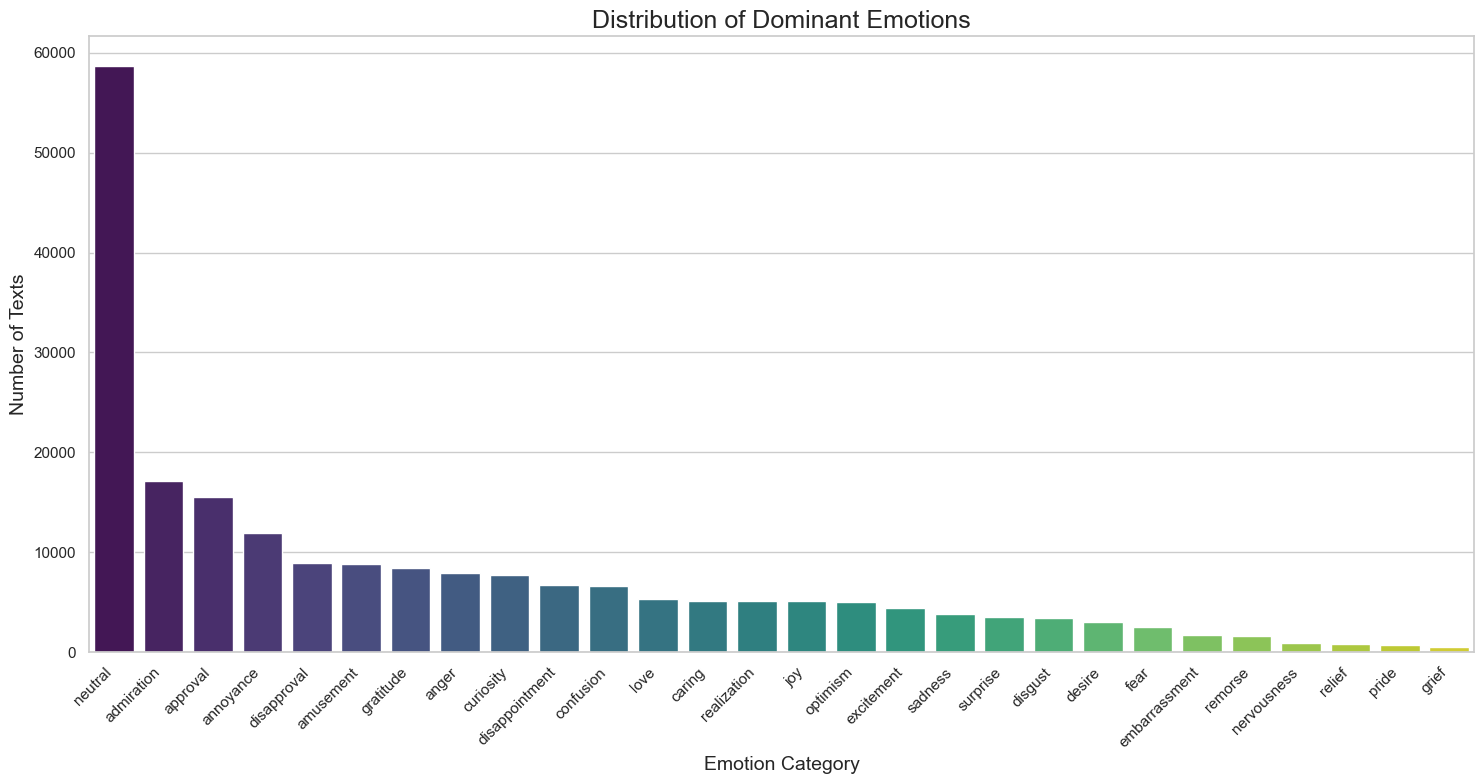

In [8]:
plt.figure(figsize=(15, 8))
emotion_counts = full_df['dominant_emotion'].value_counts()

sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.title('Distribution of Dominant Emotions', fontsize=18)
plt.ylabel('Number of Texts', fontsize=14)
plt.xlabel('Emotion Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Text Length Analysis
To tune our NLP tokenizers (like Tfidf max_features or huggingface constraints), we analyze the distribution of sequence lengths.


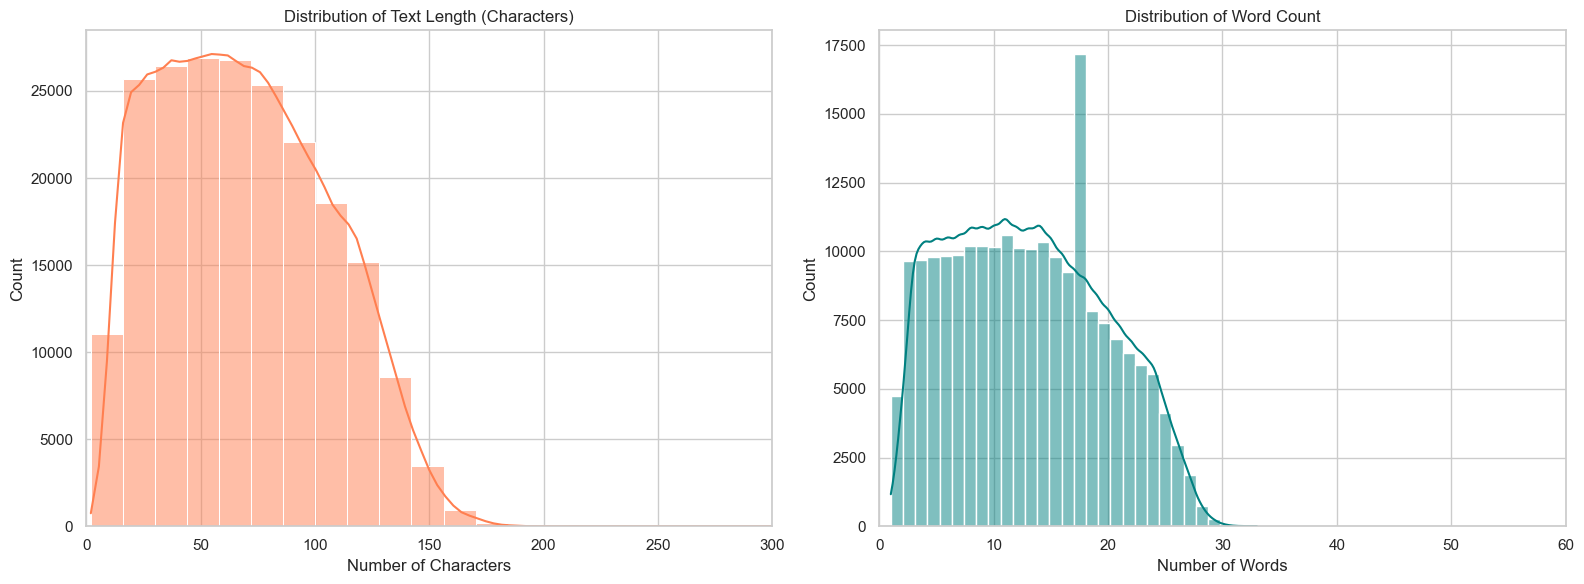

Average Words per Text: 13.00
Max Words in a Text: 33


In [9]:
# Calculate string length of each text
full_df['text_length'] = full_df['text'].astype(str).apply(len)
full_df['word_count'] = full_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(full_df['text_length'], bins=50, ax=axes[0], color='coral', kde=True)
axes[0].set_title('Distribution of Text Length (Characters)')
axes[0].set_xlabel('Number of Characters')
axes[0].set_xlim(0, 300)

sns.histplot(full_df['word_count'], bins=30, ax=axes[1], color='teal', kde=True)
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Number of Words')
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.show()

print(f"Average Words per Text: {full_df['word_count'].mean():.2f}")
print(f"Max Words in a Text: {full_df['word_count'].max()}")


## 5. Word Clouds by Key Sentiment
Let's see what the most common words are for 'Joy', 'Anger', and 'Sadness'.


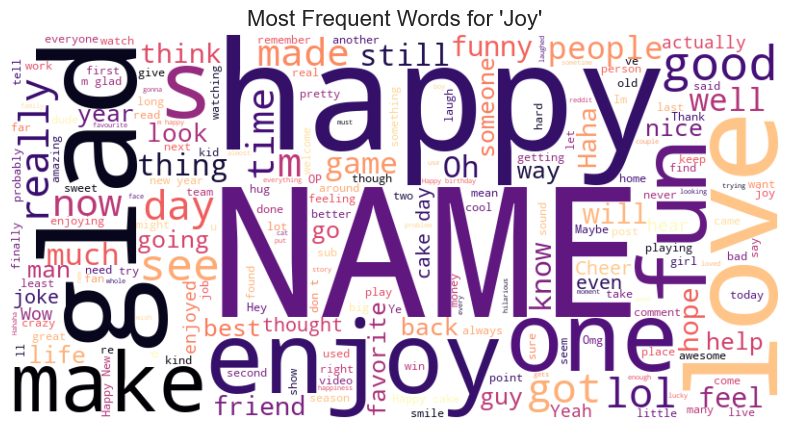

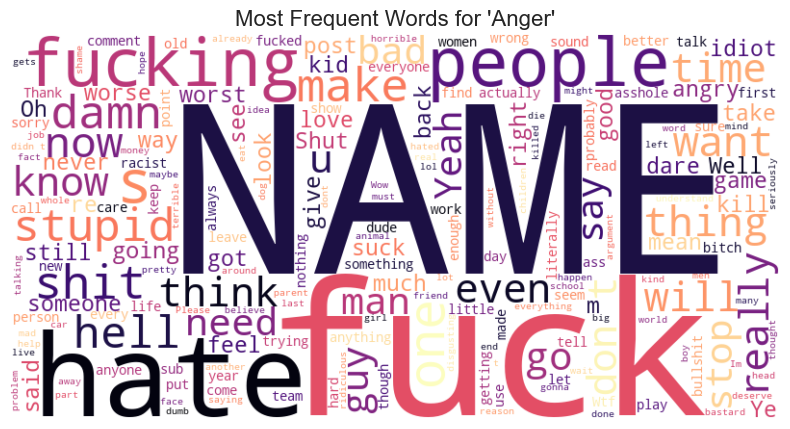

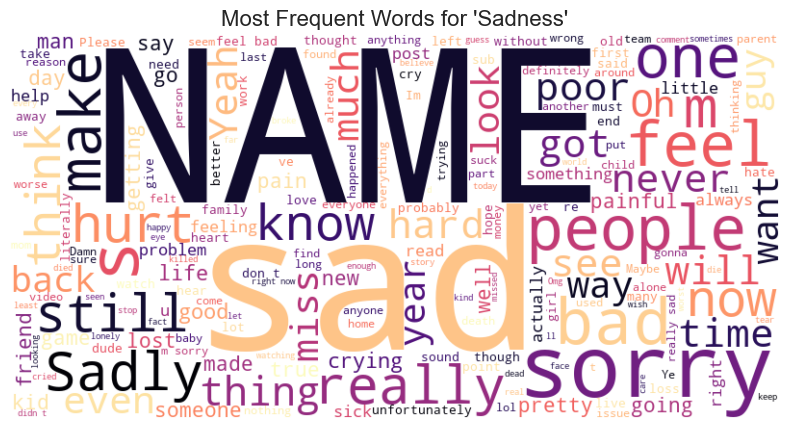

In [10]:
def plot_wordcloud(emotion_label, title):
    subset_text = " ".join(full_df[full_df['dominant_emotion'] == emotion_label]['text'].astype(str))
    
    if len(subset_text) < 10:
        print(f"Not enough data for {emotion_label}")
        return
        
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(subset_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

# Visualize positive sentiment
plot_wordcloud('joy', 'Most Frequent Words for \'Joy\'')

# Visualize negative sentiment
plot_wordcloud('anger', 'Most Frequent Words for \'Anger\'')
plot_wordcloud('sadness', 'Most Frequent Words for \'Sadness\'')
